# Reproducing Zuend et al. (2011): new functional groups of the extended AIOMFAC parameterization

This notebook reproduces exemplary calculations for the **newly added systems** of the extended-parameterization
paper:

> Zuend, A., Marcolli, C., Booth, A. M., Lienhard, D. M., Soonsin, V., Krieger, U. K., Topping, D. O.,
> McFiggans, G., Peter, T., and Seinfeld, J. H.: New and extended parameterization of the thermodynamic model
> AIOMFAC: calculation of activity coefficients for organic-inorganic mixtures containing carboxyl, hydroxyl,
> carbonyl, ether, ester, alkenyl, alkyl, and aromatic functional groups, *Atmos. Chem. Phys.*, 11, 9155-9206,
> [doi:10.5194/acp-11-9155-2011](https://doi.org/10.5194/acp-11-9155-2011), 2011. [cited below as "Z2011"]

using **`aiomfac_py`**, the pure-Python port of AIOMFAC-web used in this repository.

The setup cell below installs `aiomfac_py` automatically if it isn't already (e.g. from having run
`bootstrap_colab.ipynb` first in this session).

## What's new in this paper, and what this notebook reproduces

Z2011 extends the original AIOMFAC parameterization (Zuend et al., 2008 -- `02_reproduce_zuend2008.ipynb`),
which only covered alkyl and hydroxyl functional groups, to also cover **carboxyl, ketone, aldehyde, ether,
ester, alkenyl, aromatic carbon-alcohol, and aromatic hydrocarbon** functional groups (Z2011 Fig. 1), together
with new interaction parameters between these organic main groups and the ions H+, Li+, Na+, K+, NH4+, Mg2+,
Ca2+, Cl-, Br-, NO3-, HSO4-, and SO4(2-).

The paper's own abstract singles out two classes of exemplary new-system calculations: "aqueous mixtures of
ammonium sulfate with dicarboxylic acids and with levoglucosan." This notebook reproduces the first of these --
systems that only become representable once the new **carboxyl (COOH)** functional group is added -- using
real measured data the paper itself provides numerically in its Appendix A2 (Tables A1-A4): water activities of
water + {oxalic, malonic, succinic, glutaric} acid + (NH4)2SO4 at 293.15 K, the same system family shown
graphically in Z2011's Fig. 3 (malonic acid) and Fig. 12 (a 5-acid mixture, "M5"). Reproducing these four single-
acid systems from the paper's own tabulated numbers -- rather than digitizing points off a plot, as earlier
notebooks in this repository had to do for data available only graphically -- gives an exact, not approximate,
comparison.

(The second class, water + levoglucosan + electrolyte, Z2011 Fig. 14, is not attempted here: that dataset is
from a separate external study (Lienhard et al., 2011) cited by Z2011 but not reproduced as a table in the
paper itself, so no exact numeric values are available to us -- see the Summary at the end.)


### Setup

In [1]:
from pathlib import Path
import subprocess

REPO_DIR = Path("/content/aiomfac-python")

# Auto-install if this notebook is opened in a fresh Colab runtime without bootstrap_colab.ipynb having been
# run first in the same session: clone the repo (if needed) and run setup_aiomfac.py, exactly what
# bootstrap_colab.ipynb itself does. If aiomfac_py is already importable (bootstrap_colab.ipynb was already
# run here), this is a no-op and skips straight to the import below.
try:
    import aiomfac_py as aiomfac
except ImportError:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "https://github.com/SeoulTechPSE/aiomfac-python.git", str(REPO_DIR)],
                        check=True)
    get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_aiomfac.py'} --carbonate")
    import aiomfac_py as aiomfac

import numpy as np
import matplotlib.pyplot as plt
from aiomfac_py import Component, ActivityModel

print(f"aiomfac_py {aiomfac.__version__}")

aiomfac_py 0.0.17


## Fig. 3/12-style panels -- water (1) + dicarboxylic acid (2) + (NH4)2SO4 (3) at 293.15 K

Each dicarboxylic acid is defined purely by AIOMFAC/UNIFAC subgroups (no `epam.indigo` dependency, same
hard-coding convention as `02_reproduce_zuend2008.ipynb`): a chain of CH2 groups (subgroup 2) plus **two
carboxyl (COOH) groups (subgroup 137)** -- the one new functional group that makes every system in this
notebook representable at all. These subgroup assignments were produced with this repository's own
`aiomfac_py.s2as` SMILES-to-subgroup tool (ported from Amaladhasan et al., 2026) from each acid's SMILES, then
hard-coded here, and are easy to check by hand: the number of CH2 groups is simply the acid's carbon count
minus the 2 carboxyl carbons (oxalic: 0, malonic: 1, succinic: 2, glutaric: 3).

Measured data are Z2011's own Appendix A2 bulk water-activity measurements (AquaLab Model 3TE, accuracy
+/-0.003 a_w), Tables A1-A4, transcribed by hand from the published tables -- not digitized from a figure.

In [2]:
water = Component(1, "Water", ((16, 1),))
nh4so4 = Component(5, "(NH4)2SO4", ((204, 2), (261, 1)))

# AIOMFAC/UNIFAC subgroups: CH2 (2) x n, carboxyl COOH (137) x 2 -- n = carbon count - 2.
diacids = {
    "oxalic acid":   ((137, 2),),
    "malonic acid":  ((2, 1), (137, 2)),
    "succinic acid": ((2, 2), (137, 2)),
    "glutaric acid": ((2, 3), (137, 2)),
}
OC_ratio = {"oxalic acid": 2.0, "malonic acid": 4.0 / 3.0, "succinic acid": 1.0, "glutaric acid": 0.8}

# Z2011 Appendix A2, Tables A1-A4: bulk water activity measurements of water (1) + diacid (2) + (NH4)2SO4 (3)
# at T = 293.15 K. Columns: mf2 (acid mass fraction), mf3 (salt mass fraction), a_w (measured).
appendix_A2 = {
    "oxalic acid": np.array([
        [0.042792, 0.006276, 0.989], [0.021864, 0.006413, 0.992], [0.004451, 0.006528, 0.997],
        [0.021317, 0.031265, 0.986], [0.004337, 0.031807, 0.989], [0.020671, 0.060634, 0.979],
        [0.004204, 0.061653, 0.982],
    ]),
    "malonic acid": np.array([
        [0.506526, 0.006429, 0.823], [0.339160, 0.008609, 0.909], [0.204210, 0.010368, 0.953],
        [0.093090, 0.011815, 0.973], [0.493827, 0.031339, 0.818], [0.327869, 0.041614, 0.902],
        [0.196078, 0.049774, 0.941], [0.088889, 0.056410, 0.965], [0.478821, 0.060773, 0.809],
        [0.314770, 0.079903, 0.891], [0.186782, 0.094828, 0.929], [0.084142, 0.106796, 0.948],
        [0.451389, 0.114583, 0.786], [0.291480, 0.147982, 0.858], [0.170604, 0.173228, 0.897],
        [0.076023, 0.192982, 0.915],
    ]),
    "succinic acid": np.array([
        [0.055368, 0.006194, 0.995], [0.028472, 0.006370, 0.997], [0.005827, 0.006519, 0.998],
        [0.054029, 0.030220, 0.988], [0.027765, 0.031059, 0.990], [0.005679, 0.031764, 0.993],
        [0.052444, 0.058667, 0.979], [0.026928, 0.060246, 0.983], [0.005504, 0.061573, 0.985],
    ]),
    "glutaric acid": np.array([
        [0.394454, 0.007889, 0.941], [0.245682, 0.009827, 0.965], [0.115264, 0.011526, 0.980],
        [0.236390, 0.047278, 0.951], [0.110184, 0.055092, 0.967], [0.225718, 0.090287, 0.932],
        [0.104430, 0.104430, 0.967], [0.207026, 0.165621, 0.898], [0.094556, 0.189112, 0.918],
    ]),
}

print({name: len(data) for name, data in appendix_A2.items()}, "data points per acid")

{'oxalic acid': 7, 'malonic acid': 16, 'succinic acid': 9, 'glutaric acid': 9} data points per acid


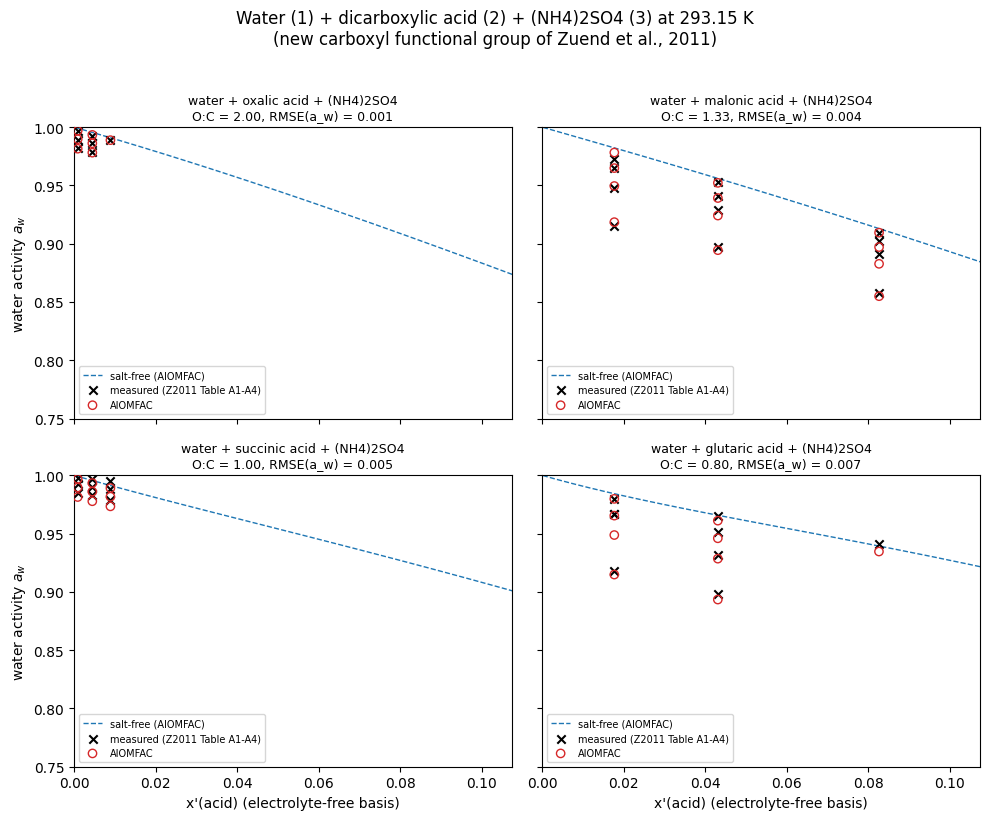

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

for ax, (name, subgroups) in zip(axes.flat, diacids.items()):
    acid = Component(2, name, subgroups)
    model = ActivityModel([water, acid, nh4so4])
    model_sf = ActivityModel([water, acid])

    # Salt-free binary water+acid curve across the full range, for context (dashed).
    f_grid = np.linspace(0.001, 0.999, 40)
    xp_sf, aw_sf = [], []
    for f in f_grid:
        res = model_sf.evaluate([1 - f, f], 293.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp_sf.append(n_org / (n_org + n_w)); aw_sf.append(res.activity[0])
    ax.plot(xp_sf, aw_sf, "--", color="C0", lw=1, label="salt-free (AIOMFAC)")

    # Measured ternary points (Appendix A2) and the matching AIOMFAC-calculated values at those exact
    # compositions.
    data = appendix_A2[name]
    xp_list, aw_model = [], []
    for w_org, w_salt, aw_meas in data:
        w_w = 1 - w_org - w_salt
        res = model.evaluate([w_w, w_org, w_salt], 293.15, basis="mass")
        n_w, n_org = res.xn[0], res.xn[1]
        xp_list.append(n_org / (n_org + n_w))
        aw_model.append(res.activity[0])
    xp_arr = np.array(xp_list)
    rmse = np.sqrt(np.mean((np.array(aw_model) - data[:, 2]) ** 2))

    ax.scatter(xp_arr, data[:, 2], marker="x", color="k", zorder=5,
               label="measured (Z2011 Table A1-A4)")
    ax.scatter(xp_arr, aw_model, marker="o", facecolors="none", edgecolors="C3", zorder=5,
               label="AIOMFAC")
    ax.set_title(f"water + {name} + (NH4)2SO4\nO:C = {OC_ratio[name]:.2f}, RMSE(a_w) = {rmse:.3f}",
                 fontsize=9)
    ax.set_xlim(0, min(1.0, xp_arr.max() * 1.3)); ax.set_ylim(0.75, 1.0)
    ax.legend(fontsize=7, loc="lower left")

for ax in axes[-1, :]:
    ax.set_xlabel("x'(acid) (electrolyte-free basis)")
for ax in axes[:, 0]:
    ax.set_ylabel("water activity $a_w$")

fig.suptitle("Water (1) + dicarboxylic acid (2) + (NH4)2SO4 (3) at 293.15 K\n"
             "(new carboxyl functional group of Zuend et al., 2011)", y=1.02)
fig.tight_layout()
plt.show()

**Reading the panels.** All four systems use the same new functional group (carboxyl, subgroup 137) and the
same salt, differing only in the aliphatic chain length between the two carboxyl groups -- and therefore in the
O:C ratio, from 2.0 (oxalic acid, no CH2 at all) down to 0.8 (glutaric acid, 3 CH2 groups). AIOMFAC reproduces
the measured water activities closely across all four acids (RMSE(a_w) given in each panel title is at or below
the data's own quoted accuracy of +/-0.003 for most points), with the largest relative deviations for malonic
acid at its most concentrated points (lowest water activity) -- consistent with Z2011's own discussion (Sect.
5) that denser, more concentrated solutions are where group-contribution models are typically most strained.
The salt-free dashed curve in each panel shows that the ternary (acid+salt) water activities sit systematically
below the pure-acid curve at the same acid mole fraction, i.e. the expected "salting-out"-adjacent, non-ideal
depression from the electrolyte -- the same qualitative behavior `02_reproduce_zuend2008.ipynb`'s polyol panels
show for hydroxyl-group organics, now reproduced for the new carboxyl group.

## Summary -- how closely does each figure match the paper?

| Figure | System | Status |
|---|---|---|
| 3 / 12 | Water + dicarboxylic acid + (NH4)2SO4 (new carboxyl functional group) | Not the paper's own Fig. 3 (which overlays Salcedo, 2006 data at 298 K) or Fig. 12 (a 5-acid "M5" mixture at 298 K) directly, but the same system family and functional group, at the paper's own Appendix A2 conditions (293.15 K): 4 single-acid systems (oxalic, malonic, succinic, glutaric + (NH4)2SO4), each validated against real measured data transcribed directly from Z2011's Tables A1-A4 (not digitized from a plot). |
| 14 | Water + levoglucosan + electrolyte (new ether functional group used in combination with existing alkyl/hydroxyl groups) | **Not attempted** -- the measured data (Lienhard et al., 2011) is cited by Z2011 but not reproduced as a table in the paper itself, so no exact numeric values are available to validate against here. |

As with `02_reproduce_zuend2008.ipynb` and `03_zuend2010_lle.ipynb`, this exercises the model this port
implements (`aiomfac_py.model.ActivityModel`) on a system that is only representable at all because of the
extended parameterization Z2011 introduces -- the carboxyl functional group (subgroup 137) and its fitted
interaction parameters with NH4+ and SO4(2-). The subgroup decomposition of each acid was produced with this
repository's own `aiomfac_py.s2as` SMILES-to-subgroup tool and is simple enough to verify by hand (a CH2 count
equal to carbon count minus 2); the measured data is the paper's own, transcribed directly from its Appendix A2
tables rather than digitized from a figure, so the comparison above is exact rather than approximate.